Python path updated with: /Users/zayed/Desktop/learning/image-classifier


100%|██████████| 170498071/170498071 [00:05<00:00, 33324318.24it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.023529384422302235..1.0000000532150268].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9659271205684234e-08..0.9803922029495239].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.015686256790161168..1.0000000532150268].


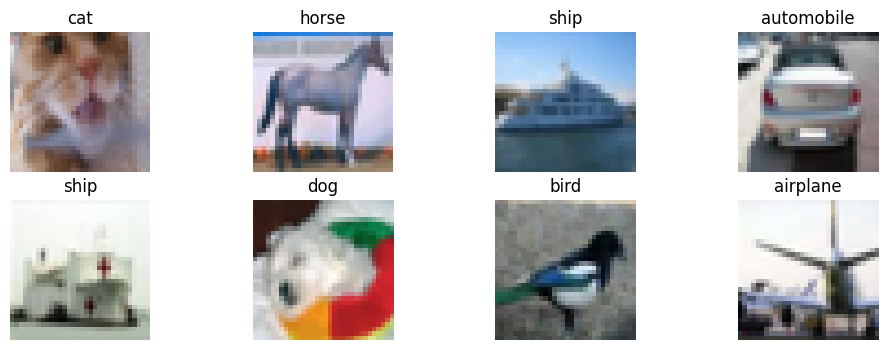

In [2]:
import sys, os

# Get the parent directory of the current notebook (.. from notebooks/)
parent_dir = os.path.abspath("..")

# Add it to Python path if not already there
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

print("Python path updated with:", parent_dir)


import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from src.dataset import get_dataloaders
from src.config import BATCH_SIZE

# Load data
train_loader, val_loader, test_loader = get_dataloaders()

# Get 1 batch
images, labels = next(iter(train_loader))

# CIFAR-10 class names
classes = [
    'airplane', 'automobile', 'bird', 'cat',
    'deer', 'dog', 'frog', 'horse', 'ship', 'truck'
]

# Undo normalization so colors look correct
def denormalize(img):
    img = img * np.array([0.2470, 0.2435, 0.2616]).reshape(3,1,1)
    img = img + np.array([0.4914, 0.4822, 0.4465]).reshape(3,1,1)
    return img

# Plot first 8 images
plt.figure(figsize=(12,4))

for i in range(8):
    img = images[i].numpy()
    img = denormalize(img).transpose(1, 2, 0)  # CHW → HWC

    plt.subplot(2, 4, i+1)
    plt.imshow(img)
    plt.title(classes[labels[i].item()])
    plt.axis("off")

plt.show()
